# **DAY 3**

In [10]:
"""
DAY 3 - PRACTICE 1: Data Augmentation Techniques
Goal: Learn how augmentations improve model performance
"""

import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random
import os

#  1. LOAD REAL IMAGE 
print("\n1. Loading your real image...")

def load_real_image():
    """Load your real image from the specified path"""
    image_path = "/kaggle/input/datasets/sanaullah03041417973/imagetesting"
    
    # Check if path exists
    if os.path.exists(image_path):
        if os.path.isdir(image_path):
            # Find first image in directory
            image_files = [f for f in os.listdir(image_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
            if image_files:
                full_path = os.path.join(image_path, image_files[0])
                print(f"   Loading image: {image_files[0]}")
                img = Image.open(full_path)
                print(f"   ✅ Image loaded successfully!")
                print(f"   Image size: {img.size}")
                print(f"   Image mode: {img.mode}")
                return img
        else:
            # Direct file path
            img = Image.open(image_path)
            print(f"   ✅ Image loaded successfully!")
            print(f"   Image size: {img.size}")
            print(f"   Image mode: {img.mode}")
            return img
    
    print("   ❌ Image not found! Please check the path.")
    print("   Creating a fallback image...")
    # Fallback: create a simple image
    img = np.zeros((100, 100, 3), dtype=np.uint8)
    for i in range(100):
        for j in range(100):
            if (i-50)**2 + (j-50)**2 < 400:
                img[i, j] = [255, 100, 100]
            elif (i-50)**2 + (j-50)**2 < 900:
                img[i, j] = [100, 255, 100]
    return Image.fromarray(img)

image = load_real_image()
print("Image ready for augmentation")




1. Loading your real image...
   Loading image: knowledge.jpg
   ✅ Image loaded successfully!
   Image size: (640, 640)
   Image mode: RGB
Image ready for augmentation



2. Geometric augmentations...


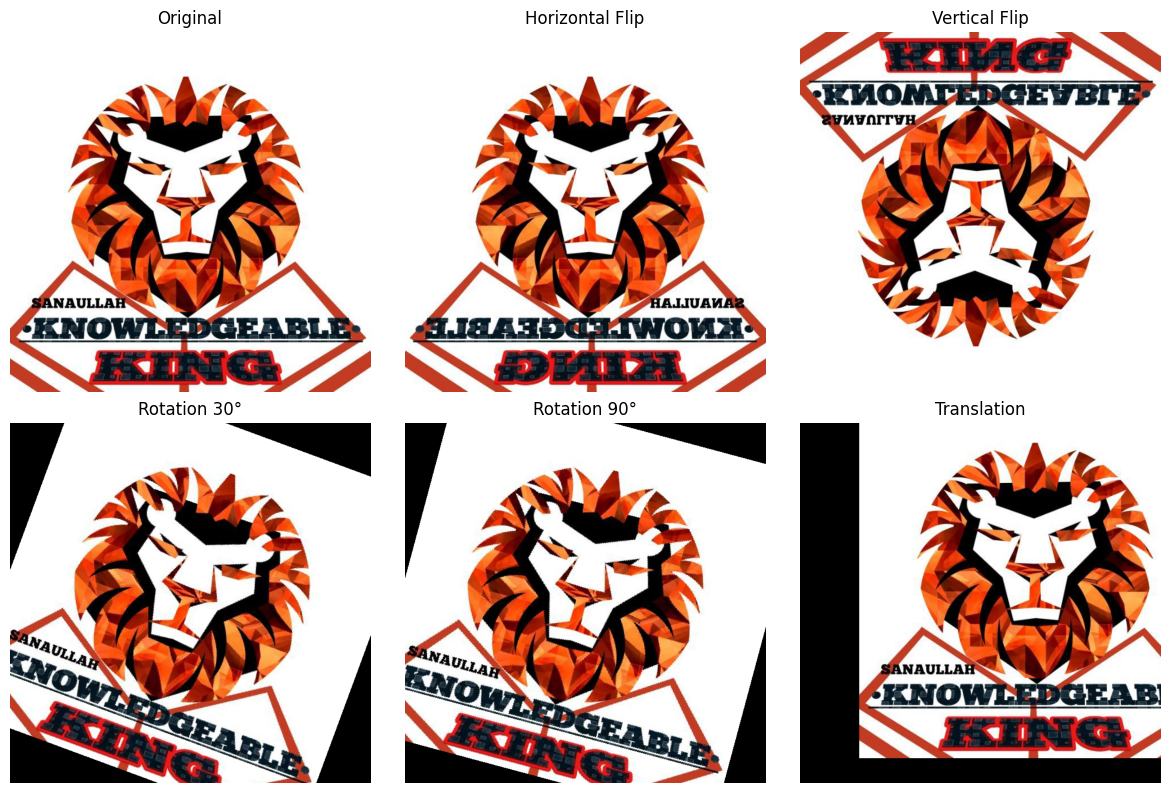

In [11]:
#  2. GEOMETRIC AUGMENTATIONS 
print("\n2. Geometric augmentations...")

# List of geometric transforms
geometric_transforms = {
    'Original': None,
    'Horizontal Flip': transforms.RandomHorizontalFlip(p=1.0),
    'Vertical Flip': transforms.RandomVerticalFlip(p=1.0),
    'Rotation 30°': transforms.RandomRotation(degrees=30),
    'Rotation 90°': transforms.RandomRotation(degrees=90),
    'Translation': transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
}

# Apply and visualize
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for idx, (name, transform) in enumerate(geometric_transforms.items()):
    if idx >= 6:
        break
    
    if transform is None:
        img = image
    else:
        img = transform(image)
    
    axes[idx].imshow(np.array(img))
    axes[idx].set_title(name)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('day3_practice1_geometric_transforms.png', dpi=150)
plt.show()


3. Color augmentations...


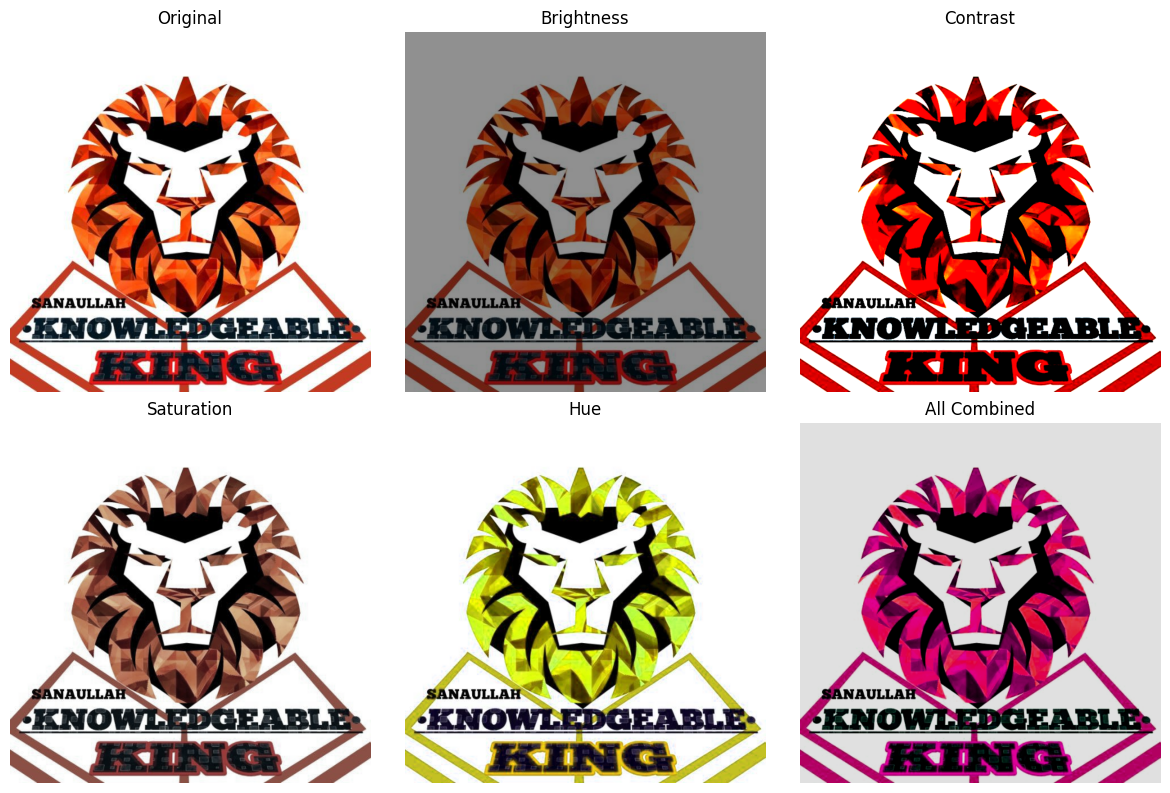

In [12]:
#  3. COLOR AUGMENTATIONS 
print("\n3. Color augmentations...")

# List of color transforms
color_transforms = {
    'Original': None,
    'Brightness': transforms.ColorJitter(brightness=2.0),
    'Contrast': transforms.ColorJitter(contrast=2.0),
    'Saturation': transforms.ColorJitter(saturation=2.0),
    'Hue': transforms.ColorJitter(hue=0.3),
    'All Combined': transforms.ColorJitter(brightness=0.5, contrast=0.5, 
                                          saturation=0.5, hue=0.2),
}

# Apply and visualize
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for idx, (name, transform) in enumerate(color_transforms.items()):
    if idx >= 6:
        break
    
    if transform is None:
        img = image
    else:
        img = transform(image)
    
    axes[idx].imshow(np.array(img))
    axes[idx].set_title(name)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('day3_practice1_color_transforms.png', dpi=150)
plt.show()


4. Advanced augmentations...


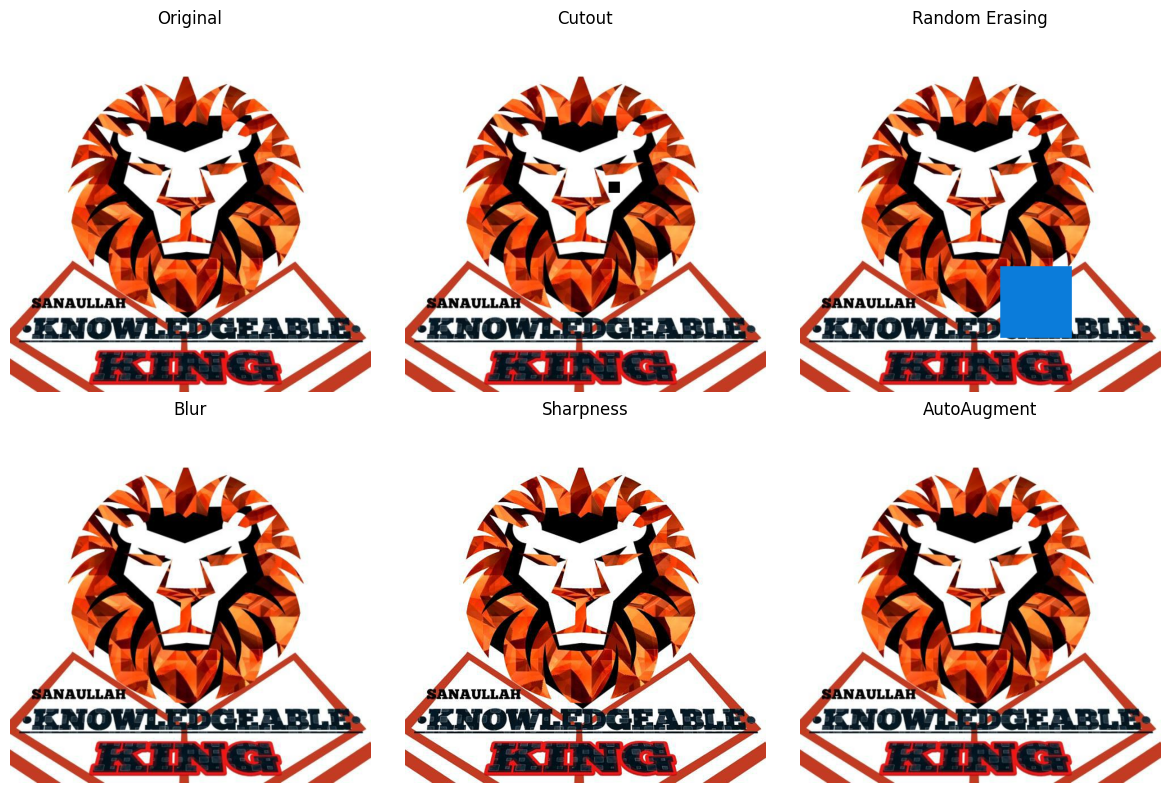

In [13]:
#  4. ADVANCED AUGMENTATIONS 
print("\n4. Advanced augmentations...")

class Cutout:
    """Cutout augmentation"""
    def __init__(self, size=20):
        self.size = size
    
    def __call__(self, img):
        img = np.array(img)
        h, w = img.shape[:2]
        
        # Random position
        x = random.randint(0, w - self.size)
        y = random.randint(0, h - self.size)
        
        # Cut out region
        img[y:y+self.size, x:x+self.size] = 0
        
        return Image.fromarray(img)

class RandomErasing:
    """Random Erasing augmentation"""
    def __init__(self, p=0.5, sl=0.02, sh=0.4):
        self.p = p
        self.sl = sl
        self.sh = sh
    
    def __call__(self, img):
        if random.random() > self.p:
            return img
        
        img = np.array(img)
        h, w = img.shape[:2]
        
        # Random rectangle size
        s = random.uniform(self.sl, self.sh)
        r_h = int(h * s)
        r_w = int(w * s)
        
        # Random position
        x = random.randint(0, w - r_w)
        y = random.randint(0, h - r_h)
        
        # Random color
        color = np.random.randint(0, 256, 3)
        
        # Erase region
        img[y:y+r_h, x:x+r_w] = color
        
        return Image.fromarray(img)

# Apply advanced augmentations
advanced_transforms = {
    'Original': None,
    'Cutout': Cutout(size=20),
    'Random Erasing': RandomErasing(p=1.0),
    'Blur': transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    'Sharpness': transforms.RandomAdjustSharpness(sharpness_factor=2.0, p=1.0),
    'AutoAugment': transforms.AutoAugment(),
}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for idx, (name, transform) in enumerate(advanced_transforms.items()):
    if idx >= 6:
        break
    
    if transform is None:
        img = image
    else:
        img = transform(image)
    
    axes[idx].imshow(np.array(img))
    axes[idx].set_title(name)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('day3_practice1_advanced_transforms.png', dpi=150)
plt.show()

In [14]:
#  5. COMPLETE AUGMENTATION PIPELINE 


def create_augmentation_pipeline(aug_level='medium'):
    
    
    mean = [0.4914, 0.4822, 0.4465]
    std = [0.2023, 0.1994, 0.2010]
    
    if aug_level == 'light':
        return transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
    
    elif aug_level == 'medium':
        return transforms.Compose([
            transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
    
    elif aug_level == 'heavy':
        return transforms.Compose([
            transforms.RandomResizedCrop(32, scale=(0.6, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=20),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])

# Show different levels
for level in ['light', 'medium', 'heavy']:
    pipeline = create_augmentation_pipeline(level)
    print(f"{level.capitalize()} augmentation has {len(pipeline.transforms)} transforms")

print("\n✅ Practice 1 Complete!")
print("- Data augmentation prevents overfitting")
print("- Geometric transforms: flip, rotate, crop, translate")
print("- Color transforms: brightness, contrast, saturation, hue")
print("- Advanced: cutout, random erasing, AutoAugment")


5. Complete augmentation pipeline for CIFAR-10...
Light augmentation has 3 transforms
Medium augmentation has 6 transforms
Heavy augmentation has 6 transforms

✅ Practice 1 Complete!
- Data augmentation prevents overfitting
- Geometric transforms: flip, rotate, crop, translate
- Color transforms: brightness, contrast, saturation, hue
- Advanced: cutout, random erasing, AutoAugment


In [20]:
"""
DAY 3 - PRACTICE 2: Training with Augmentation
Goal: Compare performance with and without augmentation
"""

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

#  1. SETUP 
print("\n1. Setting up datasets...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Define transforms
def get_transforms(use_augmentation=True):
    """Get transforms with or without augmentation"""
    mean = [0.4914, 0.4822, 0.4465]
    std = [0.2023, 0.1994, 0.2010]
    
    if use_augmentation:
        train_transform = transforms.Compose([
            transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
    else:
        train_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
    
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    
    return train_transform, test_transform

# Create datasets with and without augmentation
def create_dataloaders(use_augmentation=True):
    """Create dataloaders with or without augmentation"""
    train_transform, test_transform = get_transforms(use_augmentation)
    
    train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=train_transform
    )
    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=test_transform
    )
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    
    return train_loader, test_loader



1. Setting up datasets...
Device: cuda


In [21]:
#  2. SIMPLE CNN 
print("\n2. Creating simple CNN model...")

class SimpleCNN(nn.Module):
    """Simple CNN for CIFAR-10"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x



2. Creating simple CNN model...


In [24]:
#  3. TRAINING FUNCTION 
def train_model(train_loader, test_loader, epochs=5):
    """Train model and return history"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SimpleCNN().to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history = {'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_acc = 100 * correct / total
        
        # Validation
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_acc = 100 * correct / total
        
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}: Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")
    
    return history

In [25]:
#  4. COMPARE WITH AND WITHOUT AUGMENTATION 
print("\n4. Training without augmentation...")
train_loader_no_aug, test_loader = create_dataloaders(use_augmentation=False)
history_no_aug = train_model(train_loader_no_aug, test_loader, epochs=5)

print("\n5. Training with augmentation...")
train_loader_aug, test_loader = create_dataloaders(use_augmentation=True)
history_aug = train_model(train_loader_aug, test_loader, epochs=5)


4. Training without augmentation...


100%|██████████| 170M/170M [1:09:01<00:00, 41.2kB/s] 


Epoch 1: Train Acc: 48.01%, Val Acc: 60.86%
Epoch 2: Train Acc: 63.73%, Val Acc: 69.77%
Epoch 3: Train Acc: 69.70%, Val Acc: 70.46%
Epoch 4: Train Acc: 73.52%, Val Acc: 73.37%
Epoch 5: Train Acc: 76.12%, Val Acc: 74.42%

5. Training with augmentation...
Epoch 1: Train Acc: 42.71%, Val Acc: 55.24%
Epoch 2: Train Acc: 55.97%, Val Acc: 63.32%
Epoch 3: Train Acc: 61.64%, Val Acc: 68.71%
Epoch 4: Train Acc: 64.74%, Val Acc: 70.61%
Epoch 5: Train Acc: 67.05%, Val Acc: 70.87%



6. Visualizing comparison...


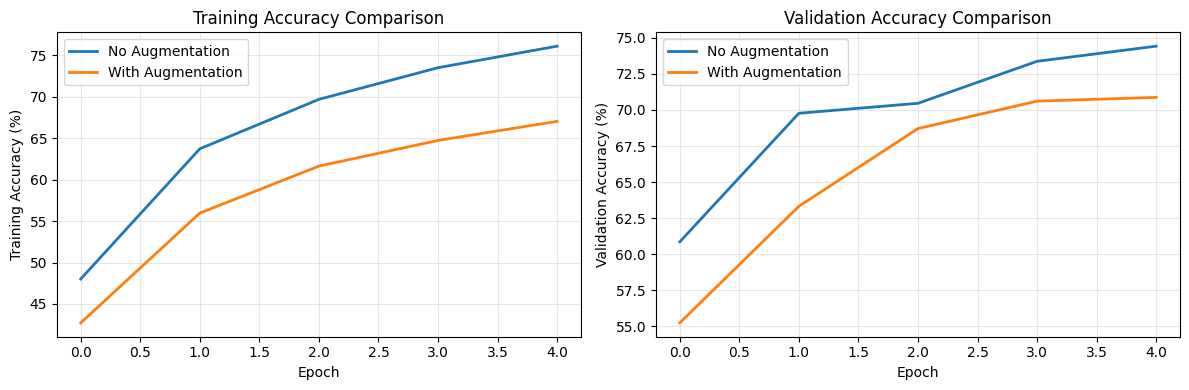


FINAL RESULTS:
Without Augmentation - Best Val Acc: 74.42%
With Augmentation - Best Val Acc: 70.87%

✅ Practice 2 Complete!
- Augmentation improves validation accuracy
- Reduces overfitting
- Essential for small datasets


In [26]:
#  5. VISUALIZE COMPARISON 
print("\n6. Visualizing comparison...")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training accuracy
axes[0].plot(history_no_aug['train_acc'], label='No Augmentation', linewidth=2)
axes[0].plot(history_aug['train_acc'], label='With Augmentation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Accuracy (%)')
axes[0].set_title('Training Accuracy Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation accuracy
axes[1].plot(history_no_aug['val_acc'], label='No Augmentation', linewidth=2)
axes[1].plot(history_aug['val_acc'], label='With Augmentation', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy (%)')
axes[1].set_title('Validation Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('day3_practice2_augmentation_comparison.png', dpi=150)
plt.show()

# Print final results
print("\n" + "=" * 40)
print("FINAL RESULTS:")
print(f"Without Augmentation - Best Val Acc: {max(history_no_aug['val_acc']):.2f}%")
print(f"With Augmentation - Best Val Acc: {max(history_aug['val_acc']):.2f}%")
print("=" * 40)

print("\n✅ Practice 2 Complete!")
print("- Augmentation improves validation accuracy")
print("- Reduces overfitting")
print("- Essential for small datasets")

In [27]:
"""
DAY 3 - PRACTICE 3: EfficientNet
Goal: Understand and use EfficientNet
"""

import torch
import torch.nn as nn
import torchvision.models as models
import time


# ============ 1. EFFICIENTNET VARIANTS ============
print("\n1. Comparing EfficientNet variants...")

# Model information
variants = {
    'B0': {'model': models.efficientnet_b0, 'input': 224, 'params': 5.3},
    'B1': {'model': models.efficientnet_b1, 'input': 240, 'params': 7.8},
    'B2': {'model': models.efficientnet_b2, 'input': 260, 'params': 9.2},
    'B3': {'model': models.efficientnet_b3, 'input': 300, 'params': 12.2},
    'B4': {'model': models.efficientnet_b4, 'input': 380, 'params': 19.3},
    'B5': {'model': models.efficientnet_b5, 'input': 456, 'params': 30.4},
    'B6': {'model': models.efficientnet_b6, 'input': 528, 'params': 43.0},
    'B7': {'model': models.efficientnet_b7, 'input': 600, 'params': 66.3},
}

print("EfficientNet Variants:")
print("-" * 50)
print(f"{'Variant':<10} {'Input Size':<12} {'Parameters (M)':<15}")
print("-" * 50)
for variant, info in variants.items():
    print(f"{variant:<10} {info['input']}x{info['input']:<7} {info['params']:<15.1f}")


1. Comparing EfficientNet variants...
EfficientNet Variants:
--------------------------------------------------
Variant    Input Size   Parameters (M) 
--------------------------------------------------
B0         224x224     5.3            
B1         240x240     7.8            
B2         260x260     9.2            
B3         300x300     12.2           
B4         380x380     19.3           
B5         456x456     30.4           
B6         528x528     43.0           
B7         600x600     66.3           


In [28]:
#  2. LOAD EFFICIENTNET 
print("\n2. Loading EfficientNet-B0...")

# Load pre-trained EfficientNet-B0
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
print("EfficientNet-B0 loaded successfully!")


2. Loading EfficientNet-B0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 139MB/s]

EfficientNet-B0 loaded successfully!


In [29]:
#  3. EXPLORE ARCHITECTURE 
print("\n3. Exploring EfficientNet architecture...")

print("Model structure:")
print("=" * 40)

# Print main components
for name, module in list(model.named_children())[:3]:
    print(f"\n{name}:")
    print(f"  Type: {type(module)}")
    if hasattr(module, 'in_features'):
        print(f"  Input features: {module.in_features}")
    if hasattr(module, 'out_features'):
        print(f"  Output features: {module.out_features}")


3. Exploring EfficientNet architecture...
Model structure:

features:
  Type: <class 'torch.nn.modules.container.Sequential'>

avgpool:
  Type: <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>

classifier:
  Type: <class 'torch.nn.modules.container.Sequential'>


In [30]:
#  4. EFFICIENTNET FEATURES 
print("\n4. EfficientNet features...")

# Input size
input_size = 224  # For B0
print(f"Input size: {input_size}x{input_size}")

# Number of parameters
params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params/1e6:.1f}M")

# Number of layers
def count_layers(module):
    count = 0
    for _ in module.modules():
        count += 1
    return count

print(f"Layers: {count_layers(model)}")


4. EfficientNet features...
Input size: 224x224
Parameters: 5.3M
Layers: 337


In [31]:
#  5. CUSTOMIZE FOR YOUR DATA 
print("\n5. Customizing EfficientNet for custom dataset...")

def customize_efficientnet(model, num_classes=10):
    """Replace classifier for custom dataset"""
    # Get input features of the classifier
    if hasattr(model, 'classifier'):
        if isinstance(model.classifier, nn.Sequential):
            in_features = model.classifier[-1].in_features
        else:
            in_features = model.classifier.in_features
    else:
        raise AttributeError("Model doesn't have 'classifier' attribute")
    
    # Replace classifier
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    
    print(f"Classifier replaced: {in_features} → {num_classes}")
    return model

# Customize model
model_custom = customize_efficientnet(model, num_classes=10)
print("\nNew classifier:")
print(model_custom.classifier)


5. Customizing EfficientNet for custom dataset...
Classifier replaced: 1280 → 10

New classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=10, bias=True)
)


In [32]:
#  6. COMPARE EFFICIENTNET WITH RESNET 
print("\n6. Comparing EfficientNet with ResNet...")

# Load ResNet
resnet = models.resnet18(weights='IMAGENET1K_V1')

# Count parameters
efficientnet_params = sum(p.numel() for p in model.parameters()) / 1e6
resnet_params = sum(p.numel() for p in resnet.parameters()) / 1e6

print(f"EfficientNet-B0: {efficientnet_params:.1f}M parameters")
print(f"ResNet18: {resnet_params:.1f}M parameters")
print(f"EfficientNet has {100 * (1 - efficientnet_params/resnet_params):.1f}% fewer parameters!")


6. Comparing EfficientNet with ResNet...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s] 

EfficientNet-B0: 4.0M parameters
ResNet18: 11.7M parameters
EfficientNet has 65.6% fewer parameters!


In [33]:
#  7. EFFICIENTNET TRAINING TIPS 
print("\n7. EfficientNet training tips...")

print("Recommended settings for EfficientNet training:")
print("1. Optimizer: RMSprop with momentum=0.9, alpha=0.9")
print("2. Learning rate: 0.001 with exponential decay")
print("3. Input size: Use appropriate size for variant")
print("4. Batch size: Adjust based on memory")
print("5. Label smoothing: 0.1 for better generalization")

print("\n✅ Practice 3 Complete!")
print("- EfficientNet uses compound scaling")
print("- Better accuracy with fewer parameters")
print("- Multiple variants for different needs")
print("- Recommended for production deployments")


7. EfficientNet training tips...
Recommended settings for EfficientNet training:
1. Optimizer: RMSprop with momentum=0.9, alpha=0.9
2. Learning rate: 0.001 with exponential decay
3. Input size: Use appropriate size for variant
4. Batch size: Adjust based on memory
5. Label smoothing: 0.1 for better generalization

✅ Practice 3 Complete!
- EfficientNet uses compound scaling
- Better accuracy with fewer parameters
- Multiple variants for different needs
- Recommended for production deployments
